In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../data/amazon_reviews_raw.csv')


In [3]:
print(df.shape)

(1597, 27)


In [4]:
print(df.columns.tolist())


['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes', 'upc', 'weight']


In [5]:
df.head(2)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams


In [6]:
df_clean = df[['name', 'reviews.text', 'reviews.rating', 'reviews.title', 'reviews.date']].copy()

df_clean.columns = ['product_name', 'review_text', 'rating', 'review_title', 'review_date']

print(df_clean.isnull().sum())

print(df_clean.shape)

df_clean.head()

product_name      0
review_text       0
rating          420
review_title     17
review_date     380
dtype: int64
(1597, 5)


,product_name,review_text,rating,review_title,review_date
0,Kindle Paperwhite,I initially had trouble deciding between the p...,5.0,"Paperwhite voyage, no regrets!",2015-08-08T00:00:00.000Z
1,Kindle Paperwhite,Allow me to preface this with a little history...,5.0,One Simply Could Not Ask For More,2015-09-01T00:00:00.000Z
2,Kindle Paperwhite,I am enjoying it so far. Great for reading. Ha...,4.0,Great for those that just want an e-reader,2015-07-20T00:00:00.000Z
3,Kindle Paperwhite,I bought one of the first Paperwhites and have...,5.0,Love / Hate relationship,2017-06-16T00:00:00.000Z
4,Kindle Paperwhite,I have to say upfront - I don't like coroporat...,5.0,I LOVE IT,2016-08-11T00:00:00.000Z


In [17]:
df_clean = df_clean.dropna(subset=['rating'])

df_clean['review_title'] = df_clean['review_title'].fillna('No Title')

print("Duplicates:", df_clean.duplicated(subset=['review_text']).sum())

df_clean = df_clean.drop_duplicates(subset=['review_text'])

print(df_clean.shape)
df_clean.isnull().sum()

Duplicates: 0
(908, 8)


product_name         0
review_text          0
rating               0
review_title         0
review_date         90
sentiment_score      0
sentiment_label      0
rating_sentiment     0
dtype: int64

In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df_clean['sentiment_score'] = df_clean['review_text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

def get_sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment_label'] = df_clean['sentiment_score'].apply(get_sentiment_label)

print(df_clean['sentiment_label'].value_counts())
df_clean[['review_text', 'rating', 'sentiment_score', 'sentiment_label']].head(10)

sentiment_label
Positive    798
Negative     70
Neutral      40
Name: count, dtype: int64


,review_text,rating,sentiment_score,sentiment_label
0,I initially had trouble deciding between the p...,5.0,0.9882,Positive
1,Allow me to preface this with a little history...,5.0,0.9886,Positive
2,I am enjoying it so far. Great for reading. Ha...,4.0,0.4364,Positive
3,I bought one of the first Paperwhites and have...,5.0,0.9755,Positive
4,I have to say upfront - I don't like coroporat...,5.0,0.9980,Positive
13,"Had older model, that you could text to speech...",4.0,0.5149,Positive
14,This is a review of the Kindle Paperwhite laun...,5.0,0.9998,Positive
15,I love my kindle! I got one for my fiance on h...,5.0,0.9785,Positive
16,"Vraiment bon petit appareil , lger et facile d...",4.0,0.0000,Neutral
17,Exactly what it is supposed to be. Works great...,5.0,0.9186,Positive


In [19]:
def rating_to_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['rating_sentiment'] = df_clean['rating'].apply(rating_to_sentiment)

match = (df_clean['sentiment_label'] == df_clean['rating_sentiment']).sum()
total = len(df_clean)
print(f"VADER aur Rating match: {match}/{total} = {round(match/total*100, 2)}%")

pd.crosstab(df_clean['rating_sentiment'], df_clean['sentiment_label'])

VADER aur Rating match: 739/908 = 81.39%


sentiment_label,Negative,Neutral,Positive
rating_sentiment,,,
Negative,29,7,36
Neutral,10,4,56
Positive,31,29,706


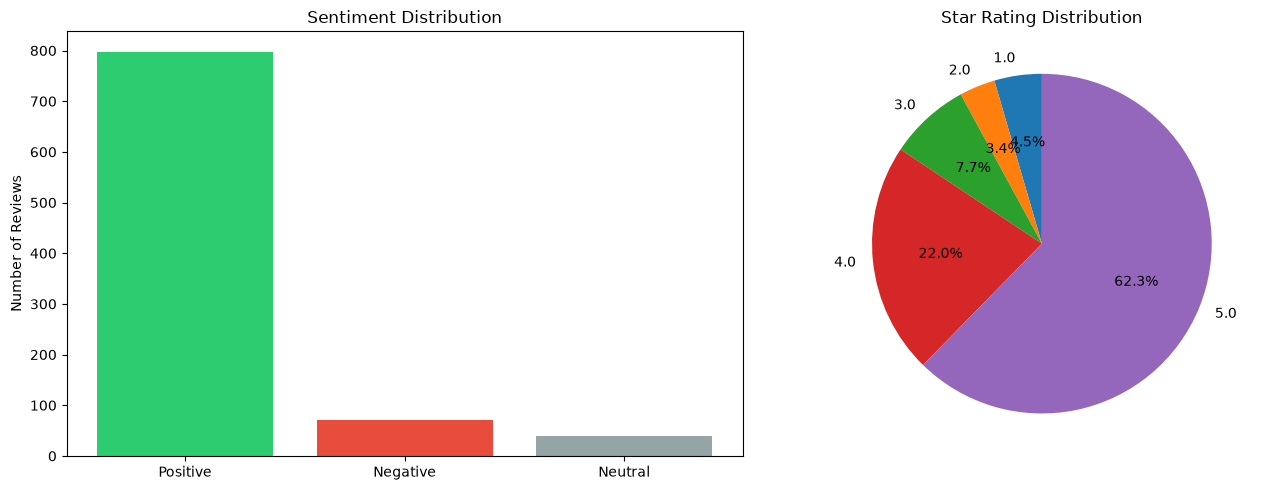

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sentiment distribution - bar chart
sentiment_counts = df_clean['sentiment_label'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=['#2ecc71', '#e74c3c', '#95a5a6'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Number of Reviews')

# 2. Rating distribution - pie chart
rating_counts = df_clean['rating'].value_counts().sort_index()
axes[1].pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Star Rating Distribution')

plt.tight_layout()
plt.savefig('sentiment_charts.png', dpi=150)
plt.show()

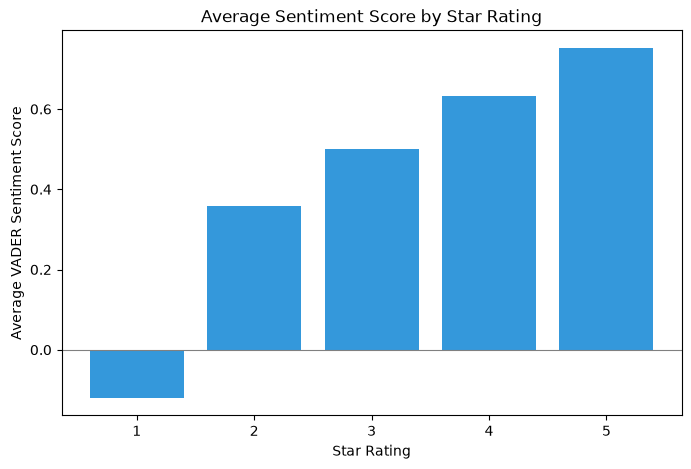

rating
1.0   -0.120232
2.0    0.357542
3.0    0.501123
4.0    0.632344
5.0    0.752195
Name: sentiment_score, dtype: float64


In [11]:
plt.figure(figsize=(8,5))
avg_sentiment_by_rating = df_clean.groupby('rating')['sentiment_score'].mean()

plt.bar(avg_sentiment_by_rating.index, avg_sentiment_by_rating.values, color='#3498db')
plt.title('Average Sentiment Score by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average VADER Sentiment Score')
plt.axhline(0, color='gray', linewidth=0.8)
plt.savefig('rating_vs_sentiment.png', dpi=150)
plt.show()

print(avg_sentiment_by_rating)

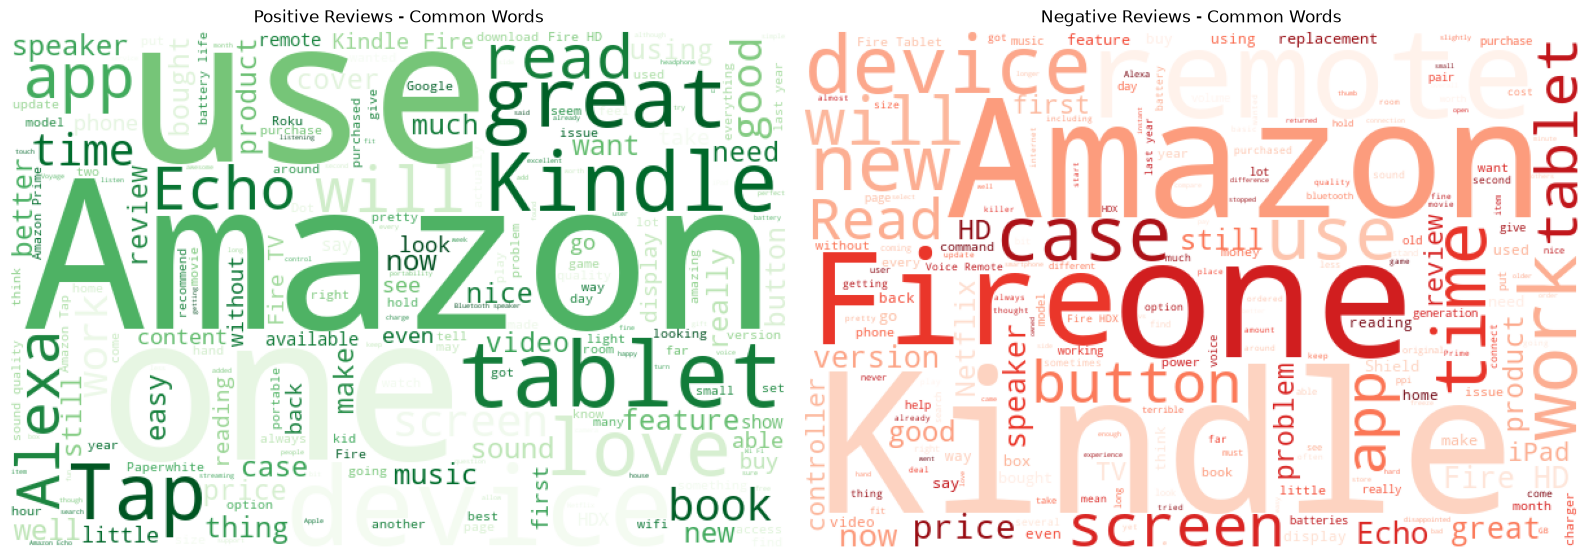

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = ' '.join(df_clean[df_clean['sentiment_label']=='Positive']['review_text'].astype(str))
negative_text = ' '.join(df_clean[df_clean['sentiment_label']=='Negative']['review_text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16,6))

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos)
axes[0].set_title('Positive Reviews - Common Words')
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg)
axes[1].set_title('Negative Reviews - Common Words')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

In [20]:
# Final cleaned dataset exported
df_clean.to_csv('amazon_reviews_cleaned.csv', index=False)
print("Saved! Shape:", df_clean.shape)
print(df_clean.columns.tolist())

Saved! Shape: (908, 8)
['product_name', 'review_text', 'rating', 'review_title', 'review_date', 'sentiment_score', 'sentiment_label', 'rating_sentiment']


In [14]:
import sqlite3

conn = sqlite3.connect('amazon_reviews.db')

df_clean.to_sql('reviews', conn, if_exists='replace', index=False)

print("Database created! Table 'reviews' ready.")

result = pd.read_sql_query("SELECT * FROM reviews LIMIT 5", conn)
result

Database created! Table 'reviews' ready.


,product_name,review_text,rating,review_title,review_date,sentiment_score,sentiment_label,rating_sentiment
0,Kindle Paperwhite,I initially had trouble deciding between the p...,5.0,"Paperwhite voyage, no regrets!",2015-08-08T00:00:00.000Z,0.9882,Positive,Positive
1,Kindle Paperwhite,Allow me to preface this with a little history...,5.0,One Simply Could Not Ask For More,2015-09-01T00:00:00.000Z,0.9886,Positive,Positive
2,Kindle Paperwhite,I am enjoying it so far. Great for reading. Ha...,4.0,Great for those that just want an e-reader,2015-07-20T00:00:00.000Z,0.4364,Positive,Positive
3,Kindle Paperwhite,I bought one of the first Paperwhites and have...,5.0,Love / Hate relationship,2017-06-16T00:00:00.000Z,0.9755,Positive,Positive
4,Kindle Paperwhite,I have to say upfront - I don't like coroporat...,5.0,I LOVE IT,2016-08-11T00:00:00.000Z,0.9980,Positive,Positive


In [21]:
query1 = """
SELECT product_name, 
       COUNT(*) as total_reviews,
       ROUND(AVG(rating), 2) as avg_rating,
       ROUND(AVG(sentiment_score), 3) as avg_sentiment
FROM reviews
GROUP BY product_name
ORDER BY total_reviews DESC
"""
print(pd.read_sql_query(query1, conn))

query2 = """
SELECT sentiment_label, COUNT(*) as count,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM reviews), 2) as percentage
FROM reviews
GROUP BY sentiment_label
ORDER BY count DESC
"""
print(pd.read_sql_query(query2, conn))

                                         product_name  total_reviews  \
0   Amazon Tap - Alexa-Enabled Portable Bluetooth ...            542   
1                                      Amazon Fire TV             31   
2   All-New Amazon Fire 7 Tablet Case (7th Generation             27   
3                                   Kindle Paperwhite             19   
4   All-New Amazon Fire HD 8 Tablet Case (7th Gene...             18   
5   Amazon 5W USB Official OEM Charger and Power A...             17   
6         Replacement Remote for Amazon Fire TV Stick             15   
7   Moshi Anti-Glare No Bubble Screen Protector fo...             12   
8   Amazon Kindle Oasis Premium Leather Battery Co...             12   
9   All-New Amazon Kid-Proof Case for Amazon Fire ...             12   
10  All-New Amazon Kid-Proof Case for Amazon Fire ...             12   
11  Alexa Voice Remote for Amazon Fire TV and Fire...             12   
12  Amazon Echo Dot Case (fits Echo Dot 2nd Genera...           

In [22]:
query3 = """
SELECT product_name,
       COUNT(*) as total_reviews,
       ROUND(AVG(sentiment_score), 3) as avg_sentiment,
       SUM(CASE WHEN sentiment_label = 'Negative' THEN 1 ELSE 0 END) as negative_count
FROM reviews
GROUP BY product_name
HAVING total_reviews >= 5
ORDER BY avg_sentiment ASC
LIMIT 10
"""
print("Worst performing products:")
print(pd.read_sql_query(query3, conn))

query4 = """
SELECT product_name, review_text, rating, sentiment_score, sentiment_label
FROM reviews
WHERE (rating >= 4 AND sentiment_label = 'Negative')
   OR (rating <= 2 AND sentiment_label = 'Positive')
LIMIT 10
"""
print("\nMismatch cases (rating vs sentiment disagree):")
print(pd.read_sql_query(query4, conn))

query5 = """
SELECT rating, COUNT(*) as count,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM reviews), 2) as percentage
FROM reviews
GROUP BY rating
ORDER BY rating
"""
print("\nRating distribution:")
print(pd.read_sql_query(query5, conn))

Worst performing products:
                                        product_name  total_reviews  \
0  Alexa Voice Remote for Amazon Fire TV and Fire...             12   
1        Replacement Remote for Amazon Fire TV Stick             15   
2            Certified Refurbished Fire HD 10 Tablet              8   
3                               Kindle Fire HDX 8.9"              5   
4      Certified Refurbished Kindle E-reader - Black              7   
5  Amazon 5W USB Official OEM Charger and Power A...             17   
6                     Amazon Fire TV Game Controller              5   
7  Moshi Anti-Glare No Bubble Screen Protector fo...             12   
8    Alexa Voice Remote for Amazon Echo and Echo Dot              7   
9             All-New Amazon Fire TV Game Controller              7   

   avg_sentiment  negative_count  
0         -0.012               5  
1          0.198               5  
2          0.201               3  
3          0.201               2  
4          0.211